In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    average_precision_score
)

In [5]:
fraud_df = pd.read_csv(
    "../data/processed/fraud_processed.csv"
)

fraud_df.head()

,purchase_value,age,ip_address,class,lower_bound_ip_address,upper_bound_ip_address,time_since_signup,hour_of_day,day_of_week,transaction_count,...,country_United States,country_Uruguay,country_Uzbekistan,country_Vanuatu,country_Venezuela,country_Viet Nam,country_Virgin Islands (U.S.),country_Yemen,country_Zambia,country_Zimbabwe
0,54,25,880217484,0,8.724152e+08,8.891924e+08,3564984.0,10,5,1,...,True,False,False,False,False,False,False,False,False,False
1,41,38,2785906106,0,2.785542e+09,2.786066e+09,10039879.0,21,5,1,...,False,False,False,False,False,False,False,False,False,False
2,47,25,356056736,0,3.523215e+08,3.690988e+08,6667201.0,11,3,1,...,True,False,False,False,False,False,False,False,False,False
3,35,19,2985180352,0,2.985034e+09,2.985296e+09,4631485.0,20,2,1,...,False,False,False,False,False,False,False,False,False,False
4,9,32,578312545,0,5.704253e+08,5.872026e+08,3193080.0,12,3,1,...,True,False,False,False,False,False,False,False,False,False


In [6]:
X = fraud_df.drop(
    columns=["class"]
)

y = fraud_df["class"]

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [9]:
from sklearn.preprocessing import StandardScaler

In [10]:
numeric_cols = X_train.select_dtypes(
    include=["int64", "float64"]
).columns

In [11]:
scaler = StandardScaler()

X_train[numeric_cols] = scaler.fit_transform(
    X_train[numeric_cols]
)

X_test[numeric_cols] = scaler.transform(
    X_test[numeric_cols]
)

In [12]:
from imblearn.over_sampling import SMOTE

In [13]:
smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = (
    smote.fit_resample(
        X_train,
        y_train
    )
)

In [14]:
y_train_smote.value_counts()

class
0    93502
1    93502
Name: count, dtype: int64

In [15]:
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [16]:
lr_model.fit(
    X_train_smote,
    y_train_smote
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [17]:
y_pred = lr_model.predict(
    X_test
)

In [18]:
y_prob = lr_model.predict_proba(
    X_test
)[:,1]

In [19]:
f1 = f1_score(
    y_test,
    y_pred
)

print(
    f"F1 Score: {f1:.4f}"
)

F1 Score: 0.3180


In [20]:
auc_pr = average_precision_score(
    y_test,
    y_prob
)

print(
    f"AUC-PR: {auc_pr:.4f}"
)

AUC-PR: 0.3443


In [21]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.95      0.74      0.83     23376
           1       0.21      0.66      0.32      2454

    accuracy                           0.73     25830
   macro avg       0.58      0.70      0.58     25830
weighted avg       0.88      0.73      0.78     25830



In [22]:
cm = confusion_matrix(
    y_test,
    y_pred
)

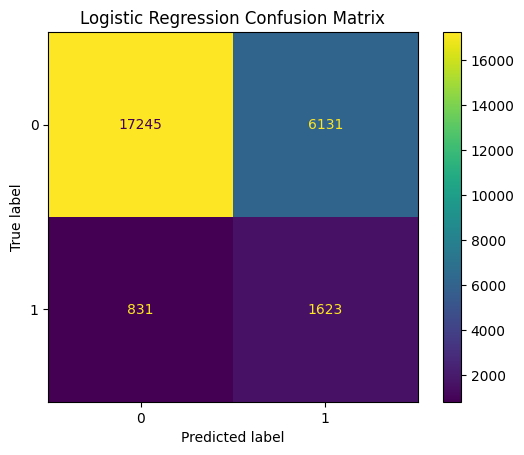

In [23]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title(
    "Logistic Regression Confusion Matrix"
)

plt.show()

In [24]:
import joblib

In [25]:
joblib.dump(
    lr_model,
    "../models/logistic_regression.pkl"
)

['../models/logistic_regression.pkl']

In [26]:
results = pd.DataFrame({
    "Model": ["Logistic Regression"],
    "F1 Score": [f1],
    "AUC-PR": [auc_pr]
})

results

,Model,F1 Score,AUC-PR
0,Logistic Regression,0.317986,0.344304


In [27]:
from sklearn.ensemble import RandomForestClassifier

In [28]:
rf_model = RandomForestClassifier(
    random_state=42
)

In [29]:
rf_model.fit(
    X_train_smote,
    y_train_smote
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [30]:
rf_pred = rf_model.predict(
    X_test
)

rf_prob = rf_model.predict_proba(
    X_test
)[:,1]

In [31]:
rf_f1 = f1_score(
    y_test,
    rf_pred
)

print(rf_f1)

0.700284458236359


In [32]:
rf_auc_pr = average_precision_score(
    y_test,
    rf_prob
)

print(rf_auc_pr)

0.6408197992318887


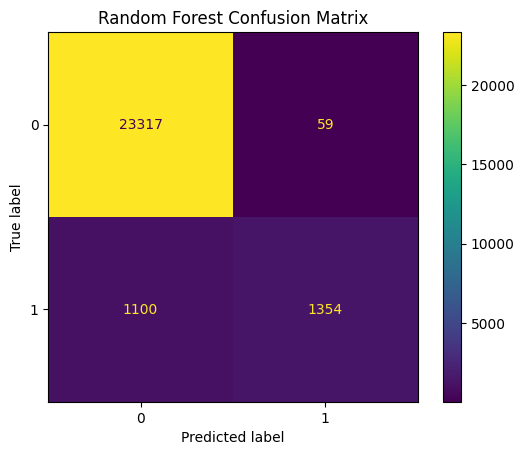

In [33]:
cm = confusion_matrix(
    y_test,
    rf_pred
)

ConfusionMatrixDisplay(
    confusion_matrix=cm
).plot()

plt.title(
    "Random Forest Confusion Matrix"
)

plt.show()

In [34]:
rf_1 = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

In [35]:
rf_2 = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    random_state=42
)

In [36]:
rf_3 = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42
)

In [37]:
def evaluate_model(model):

    model.fit(
        X_train_smote,
        y_train_smote
    )

    pred = model.predict(X_test)

    prob = model.predict_proba(X_test)[:,1]

    return (
        f1_score(y_test, pred),
        average_precision_score(
            y_test,
            prob
        )
    )

In [38]:
for model in [rf_1, rf_2, rf_3]:

    f1, auc = evaluate_model(model)

    print(
        model,
        f1,
        auc
    )

RandomForestClassifier(max_depth=10, random_state=42) 0.7068965517241379 0.6431969680549086
RandomForestClassifier(max_depth=15, n_estimators=200, random_state=42) 0.704504035407446 0.6450302096104125
RandomForestClassifier(n_estimators=300, random_state=42) 0.7010630023334198 0.6425171803073991


In [39]:
best_rf = rf_2

In [40]:
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score
)

In [41]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [42]:
lr_cv = cross_val_score(
    lr_model,
    X_train_smote,
    y_train_smote,
    cv=skf,
    scoring="f1"
)

In [43]:
print(
    lr_cv.mean()
)

print(
    lr_cv.std()
)

0.771067630204881
0.0011292699747811631


In [44]:
rf_cv = cross_val_score(
    best_rf,
    X_train_smote,
    y_train_smote,
    cv=skf,
    scoring="f1"
)

In [45]:
print(
    rf_cv.mean()
)

print(
    rf_cv.std()
)

0.7650226858058331
0.0042354879144164215


In [46]:
results = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Random Forest"
    ],

    "F1 Score":[
        f1,
        rf_f1
    ],

    "AUC-PR":[
        auc_pr,
        rf_auc_pr
    ],

    "CV Mean F1":[
        lr_cv.mean(),
        rf_cv.mean()
    ],

    "CV Std":[
        lr_cv.std(),
        rf_cv.std()
    ]
})

results

,Model,F1 Score,AUC-PR,CV Mean F1,CV Std
0,Logistic Regression,0.701063,0.344304,0.771068,0.001129
1,Random Forest,0.700284,0.640820,0.765023,0.004235


In [47]:
joblib.dump(
    lr_model,
    "../models/logistic_regression.pkl"
)

joblib.dump(
    best_rf,
    "../models/random_forest.pkl"
)

['../models/random_forest.pkl']

In [48]:
X_test.to_csv(
    "../data/processed/X_test.csv",
    index=False
)

y_test.to_csv(
    "../data/processed/y_test.csv",
    index=False
)